In [1]:
import warnings
import os
os.chdir('../../..')
from Scripts.Statistical_Tester import stat_test, export_band_table

import pandas as pd
pd.set_option("display.max_colwidth", 15)

In [2]:
band_table = export_band_table(
    npz_path="./Generated/Spectrums/exec_and_rest_morlets.npz",
    out_csv="./Supplementary/band_table.csv",
    day_time_meta_path="./Supplementary/Experiment_Metadata.xlsx",
    flush_rows=200,
)

band_table

/Data/EEG-Visual-Experiment/Scripts/Statistical_Tester.py:55: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_str = pd.to_datetime(s, errors="coerce", dayfirst=True, infer_datetime_format=True)


Export band_table:   0%|          | 0/1260 [00:00<?, ?trial/s]

,s_id,t_id,gender,handiness,age,stim_label,label,img,task_type,stim_type,...,ch60_Alpha,ch60_Beta,ch61_Delta,ch61_Tetta,ch61_Alpha,ch61_Beta,ch62_Delta,ch62_Tetta,ch62_Alpha,ch62_Beta
0,5,1,m,r,23,2,2,"[[0, 0, 0, ...",g,g,...,0.025002,0.020865,0.084367,0.048651,0.033165,0.021930,0.111683,0.073445,0.060595,0.028198
1,5,1,m,r,23,10,10,"[[0, 0, 0, ...",g,g,...,0.026853,0.018557,0.089678,0.054940,0.039961,0.020439,0.108698,0.071774,0.055675,0.027702
2,5,1,m,r,23,6,6,"[[0, 0, 1, ...",g,g,...,0.027188,0.020181,0.083475,0.048261,0.044915,0.021077,0.102447,0.069229,0.063561,0.026128
3,5,1,m,r,23,6,6,"[[0, 0, 1, ...",g,g,...,0.032066,0.019489,0.069424,0.048938,0.038794,0.018007,0.134448,0.081459,0.055009,0.028349
4,5,1,m,r,23,10,10,"[[0, 0, 0, ...",g,g,...,0.027724,0.020220,0.067615,0.042347,0.036051,0.019945,0.096268,0.055822,0.060736,0.028579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,15,2,f,r,23,-1,-1,"[[0, 1, 0, ...",r,r,...,0.092835,0.041947,0.246747,0.136917,0.093093,0.043165,0.292398,0.136691,0.099388,0.039060
1256,15,2,f,r,23,-1,-1,"[[0, 1, 0, ...",r,r,...,0.083955,0.057087,0.327342,0.174763,0.098754,0.050536,0.280078,0.146196,0.089307,0.039126
1257,15,2,f,r,23,-1,-1,"[[1, 1, 1, ...",r,r,...,0.111593,0.054036,0.211959,0.121034,0.105832,0.057375,0.236506,0.133057,0.111334,0.048176
1258,15,2,f,r,23,-1,-1,"[[0, 1, 0, ...",r,r,...,0.115503,0.053388,0.210801,0.139864,0.120814,0.050678,0.238755,0.143316,0.121778,0.045463


отличается ли спектральная мощность днём и вечером, и на каких электродах?

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


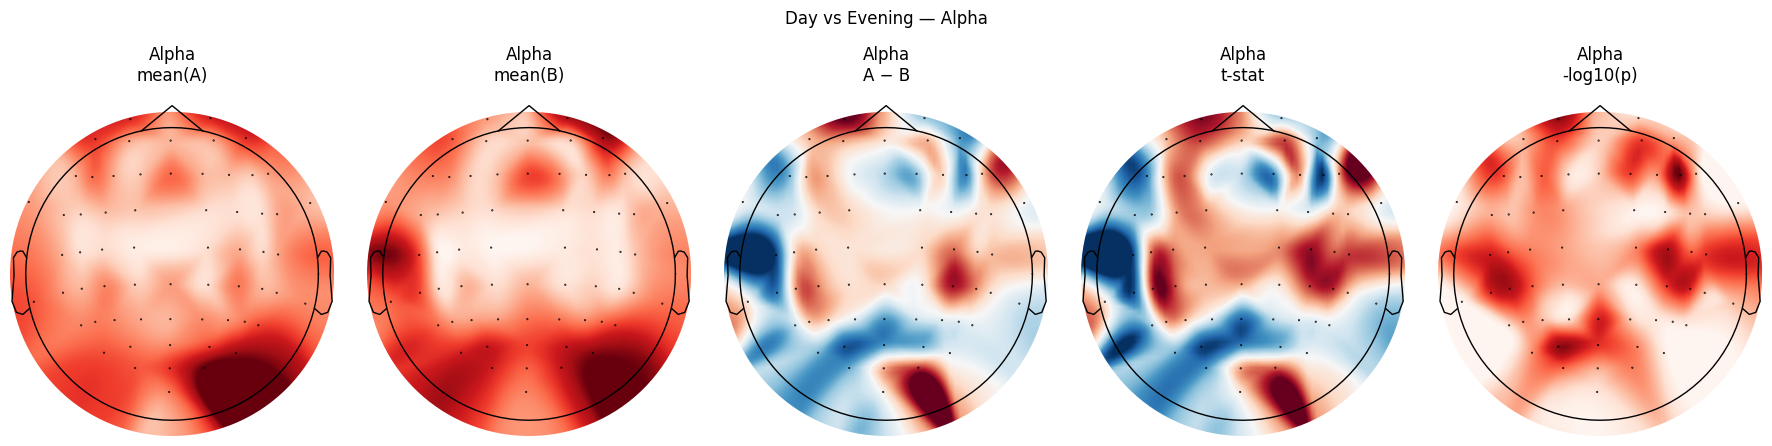

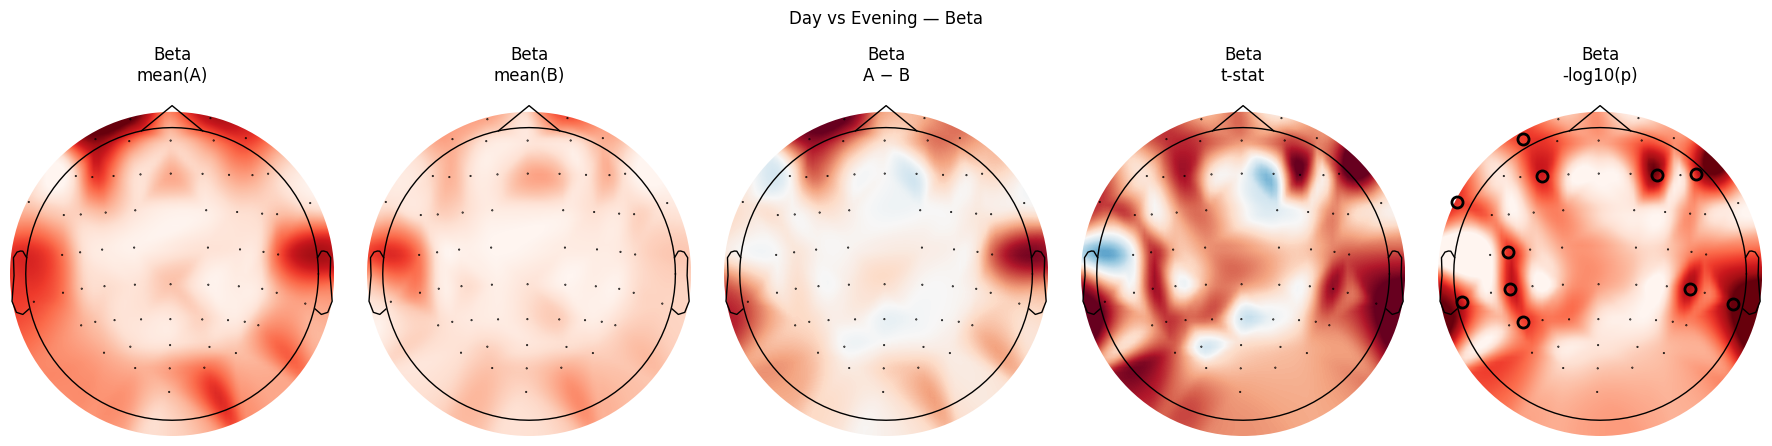

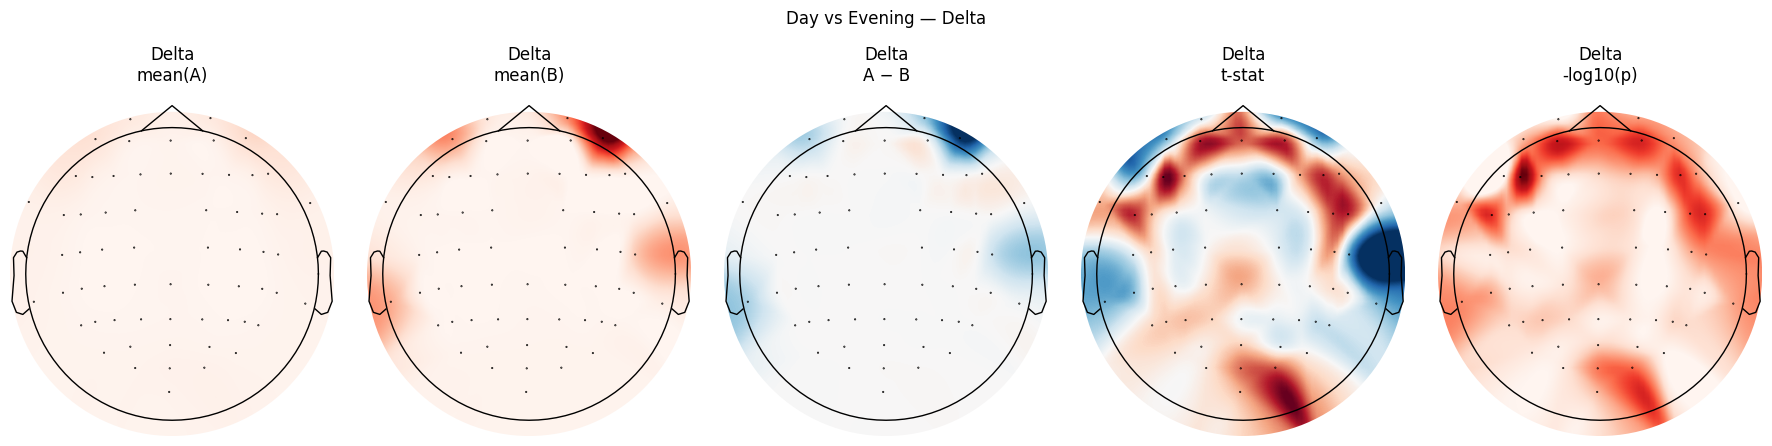

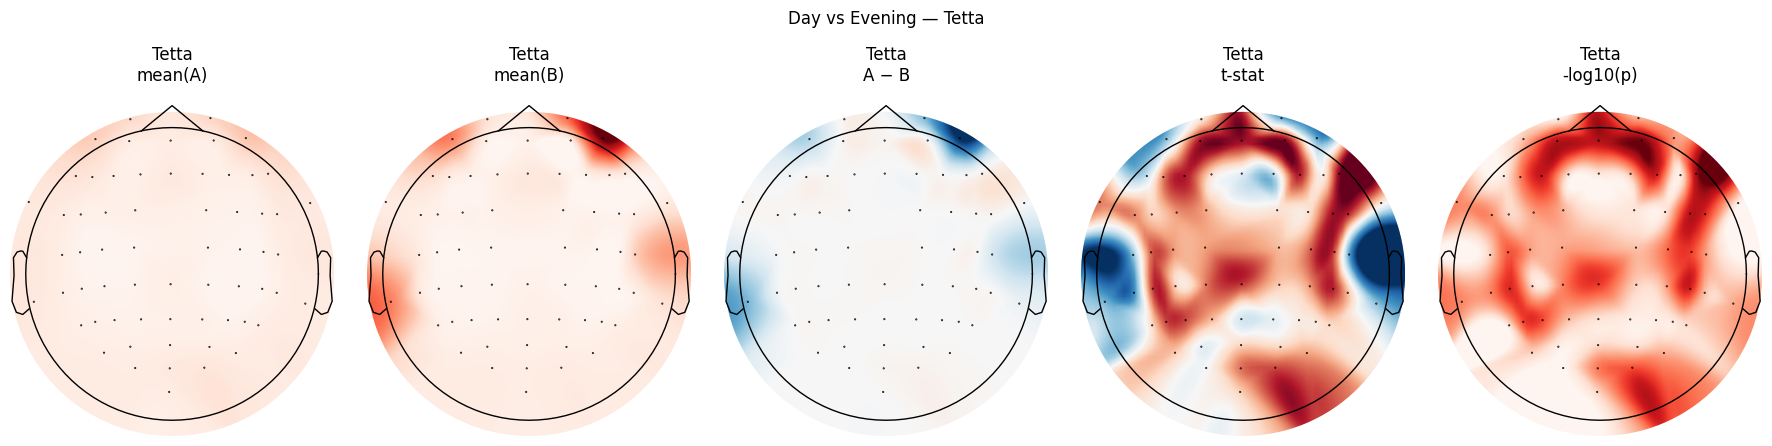

,channel,band,n_A,n_B,mean_A,mean_B,diff_A_minus_B,t_stat,p_value
0,20,Beta,14,12,0.107873,0.065647,0.042226,3.001470,0.007236
1,28,Beta,14,12,0.098199,0.045871,0.052327,2.993982,0.009300
2,21,Beta,14,12,0.046157,0.029452,0.016705,2.667143,0.014315
3,10,Beta,14,12,0.070204,0.038430,0.031774,2.537839,0.020858
4,2,Beta,14,12,0.125964,0.047977,0.077987,2.482852,0.026382
...,...,...,...,...,...,...,...,...,...
247,1,Beta,14,12,0.102423,0.101891,0.000532,0.009005,0.992940
248,25,Alpha,14,12,0.141572,0.141835,-0.000262,-0.005767,0.995449
249,15,Tetta,14,12,0.192576,0.192667,-0.000091,-0.002937,0.997685
250,37,Delta,14,12,0.219333,0.219159,0.000173,0.002922,0.997706


In [3]:
result_df, result_fig = stat_test(
                                band_table=band_table,
                                groupA={"day_time": "Day"},
                                groupB={"day_time": "Evening"},
                                test_type="t-test",
                                example_eeg="./Generated/Data/S_1/Trial_1/EEG_clean.fif",
                                level="subject",
                                title_prefix="Day vs Evening",
                                )


result_df

есть ли различия по полу именно в дневной записи?

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


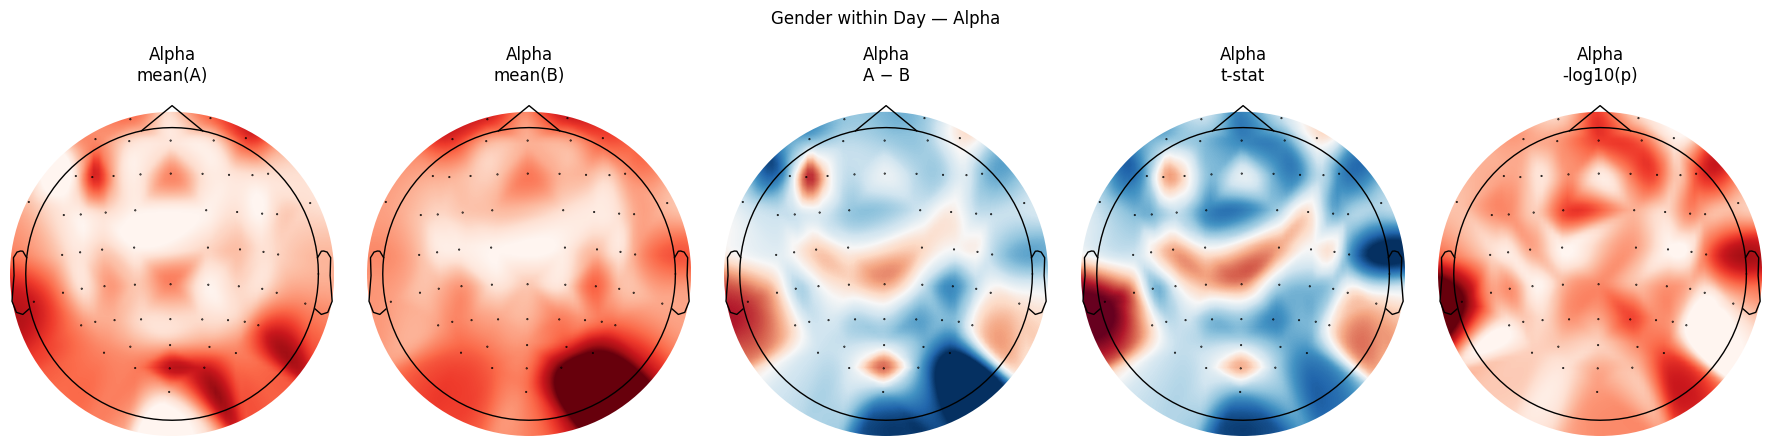

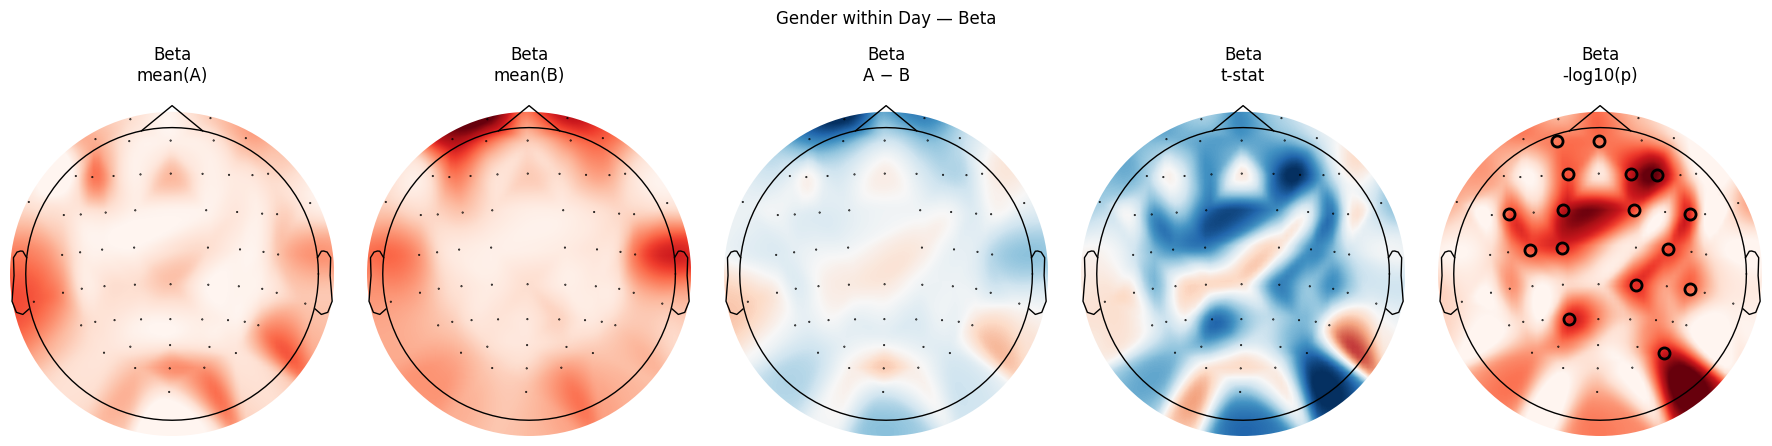

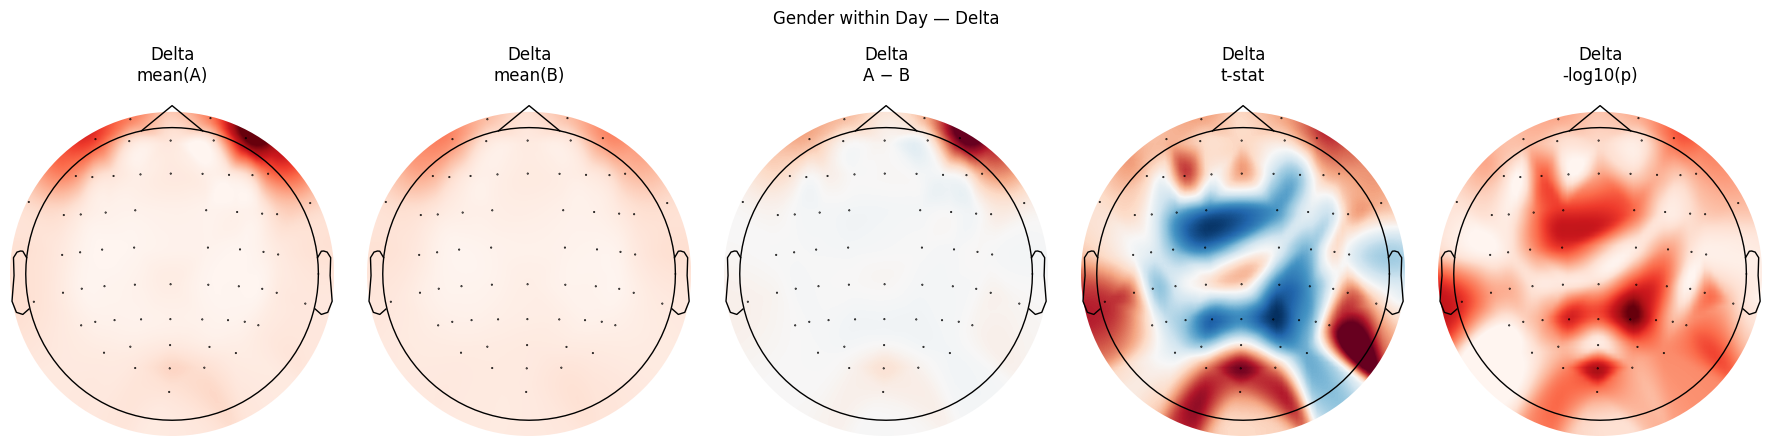

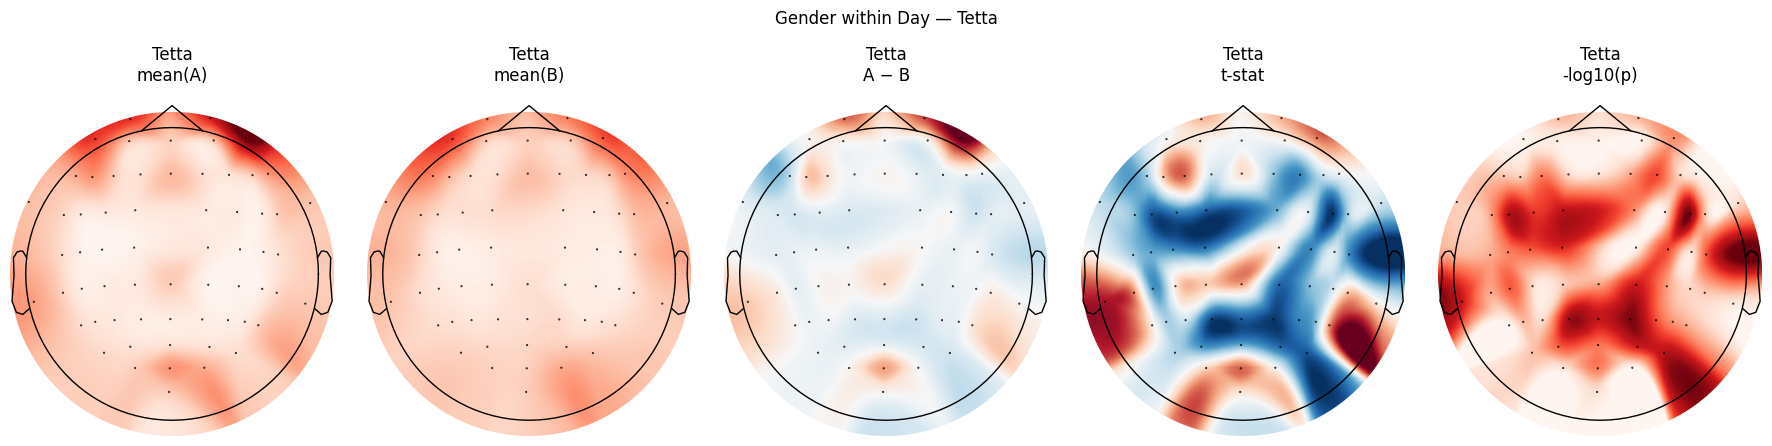

,channel,band,n_A,n_B,mean_A,mean_B,diff_A_minus_B,t_stat,p_value
0,28,Beta,5,9,0.041724,0.129573,-0.087849,-4.323866,0.001621
1,6,Beta,5,9,0.028744,0.059620,-0.030877,-3.398905,0.005318
2,61,Beta,5,9,0.036773,0.073434,-0.036661,-3.328149,0.006621
3,48,Beta,5,9,0.053556,0.099265,-0.045708,-3.147411,0.009181
4,42,Beta,5,9,0.031072,0.058062,-0.026990,-3.243194,0.010010
...,...,...,...,...,...,...,...,...,...
247,60,Tetta,5,9,0.197989,0.197074,0.000915,0.011245,0.991322
248,23,Alpha,5,9,0.148568,0.149328,-0.000761,-0.010839,0.991530
249,35,Delta,5,9,0.542965,0.544201,-0.001236,-0.005150,0.996073
250,19,Alpha,5,9,0.213227,0.213583,-0.000356,-0.004207,0.996714


In [4]:
result_df, result_fig = stat_test(
                                band_table=band_table,
                                groupA={"day_time": "Day", "gender": "m"},
                                groupB={"day_time": "Day", "gender": "f"},
                                test_type="t-test",
                                example_eeg="./Generated/Data/S_1/Trial_1/EEG_clean.fif",
                                level="subject",
                                title_prefix="Gender within Day",
                                )


result_df

эффект времени суток сохраняется внутри конкретного пола?

In [6]:
result_df, result_fig = stat_test(
                                band_table=band_table,
                                groupA={"day_time": "Day", "gender": "f"},
                                groupB={"day_time": "Evening", "gender": "f"},
                                test_type="t-test",
                                example_eeg="./Generated/Data/S_1/Trial_1/EEG_clean.fif",
                                level="subject",
                                title_prefix="Day vs Evening (Females only)",
                                )


result_df

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


ValueError: stats_table пустая: после фильтрации/агрегации слишком мало данных. Проверь значения day_time/gender в band_table.csv и/или снизь min_n, или попробуй level='trial'.

сохранить таблицу 

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


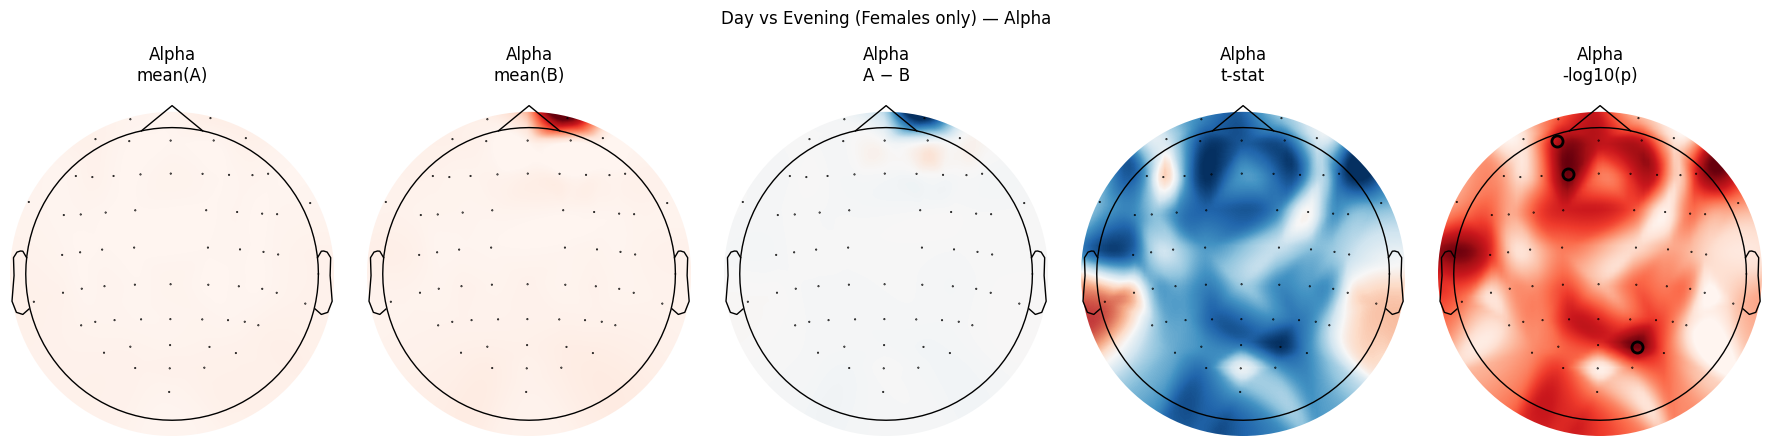

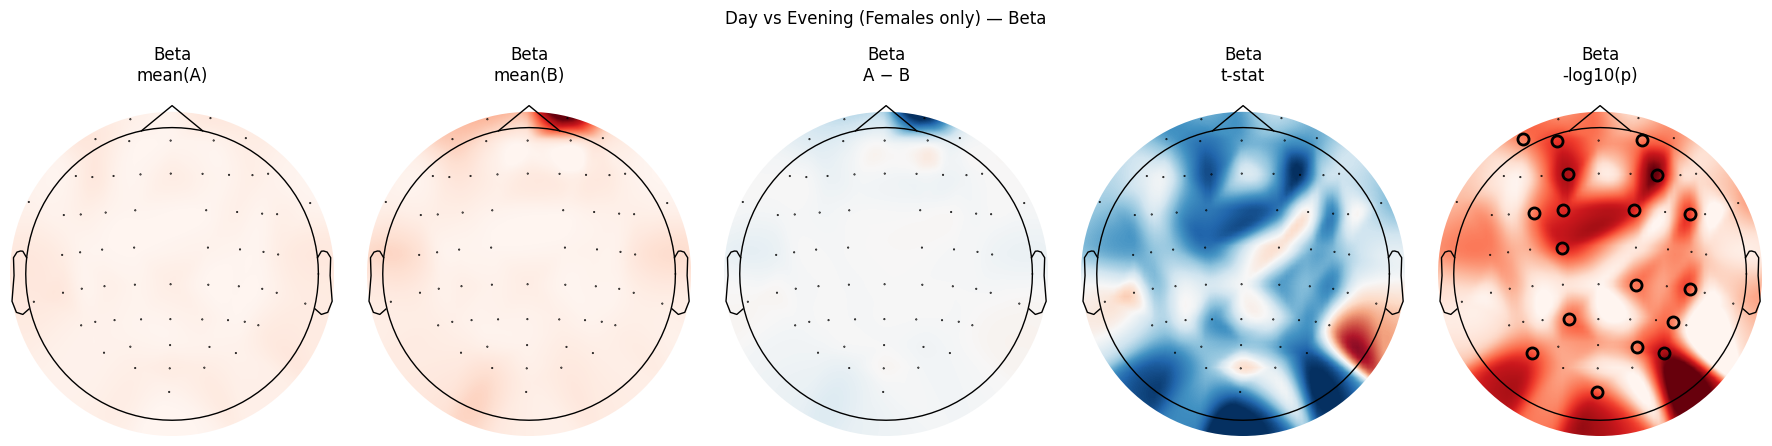

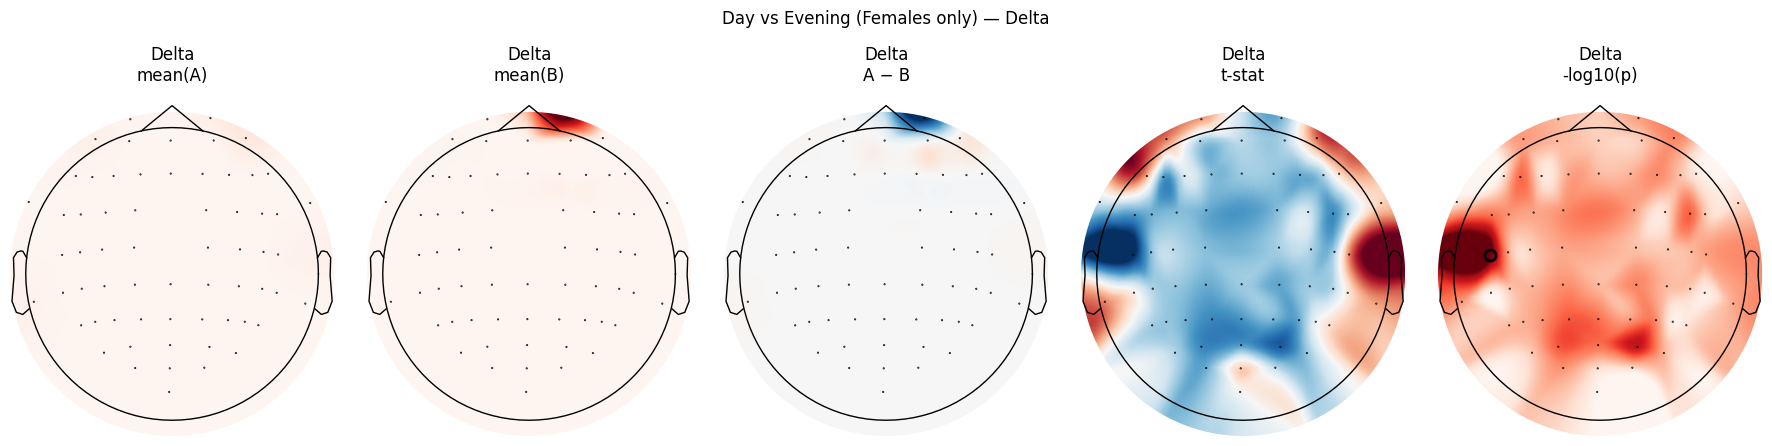

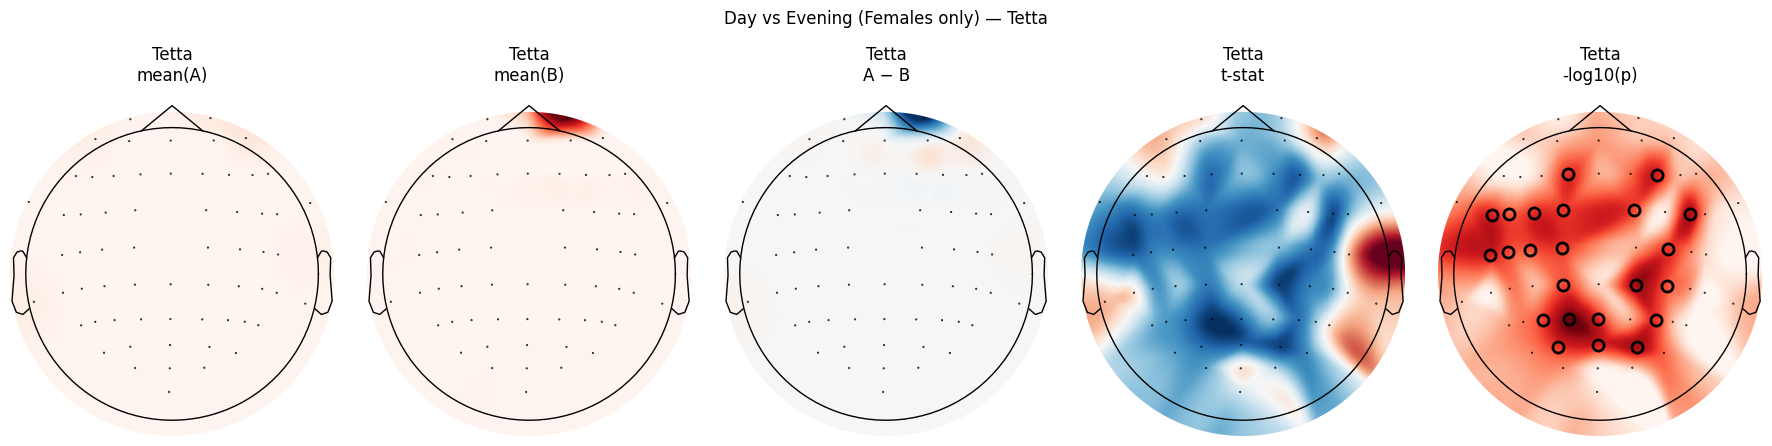

In [5]:
result_df, result_fig = stat_test(
                                band_table=band_table,
                                groupA={"gender": "m"},
                                groupB={"gender": "f"},
                                test_type="t-test",
                                example_eeg="./Generated/Data/S_1/Trial_1/EEG_clean.fif",
                                level="subject",
                                title_prefix="Day vs Evening (Females only)",
                                )

result_df.to_csv("./Supplementary/stats_gender_m_vs_f.csv", index=False)